<a href="https://colab.research.google.com/github/BBCharming/CS/blob/master/third-year/CS351/Lab2CS351.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Lab 2: Part A ##

In [ ]:
import numpy as np
import timeit, matplotlib.pyplot as plt
#horner's algorithm
def horner(coeffs, x):
    result = coeffs[0]
    counter = 0;
    for a in coeffs[1:]:
        result = result * x + a
        counter = counter + 1;
    print("number of executions = ",
          counter, " additions + ", counter,
          "multiplications = ", (counter + counter))
    return result
#polynomial coeffecients
coeff = [2, 3, -3, 5, -1];
#Horner's results
x = horner(coeff,0.5)
#polyvar results
y = np.polyval(coeff,0.5)

print("Horner's algorithm results: ", x)
print("Polyval's resuts: ",y)


number of executions =  4  additions +  4 multiplications =  8
Horner's algorithm results:  1.25
Polyval's resuts:  1.25


## Lab2: Part B ##

Text(0.5, 1.0, 'Horner vs Naïve: Timing Comparison')

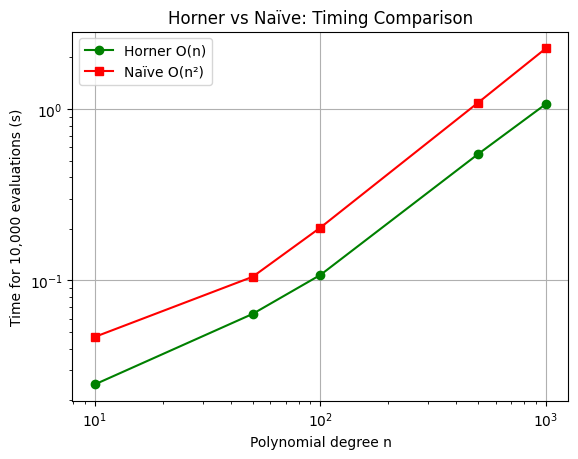

In [ ]:
import numpy as np
import timeit, matplotlib.pyplot as plt

#functions
def horner(coeffs, x):
    result = coeffs[0]
    for a in coeffs[1:]:
        result = result * x + a
    return result

def naive_eval(coeffs, x):
    return sum(c * x**(len(coeffs)-1-i)
        for i,c in enumerate(coeffs))
degrees = [10, 50, 100, 500, 1000]
times_horner, times_naive = [], []

#Analyzing time
for d in degrees:
    coeffs = list(np.random.randn(d+1))
    x_val = 1.5
    t_h = timeit.timeit(
    lambda: horner(coeffs, x_val), number=10000)
    t_n = timeit.timeit(
    lambda: naive_eval(coeffs, x_val), number=10000)
    times_horner.append(t_h)
    times_naive.append(t_n)

#plotting the degree against time graph for comparison
plt.loglog(degrees, times_horner, 'g-o', label='Horner O(n)')
plt.loglog(degrees, times_naive,  'r-s', label='Naïve O(n²)')
plt.xlabel('Polynomial degree n')
plt.ylabel('Time for 10,000 evaluations (s)')
plt.legend(); plt.grid(True)
plt.title('Horner vs Naïve: Timing Comparison')

## LAB 2: PART C

In [ ]:
import numpy as np
import matplotlib as plt

# Wilkinson polynomial: p(x) = (x-1)(x-2)...(x-20)
# at x = 2.0 (exact answer: 0, since 2 is a root)
# Coefficients of expanded Wilkinson polynomial
w = np.poly([1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20])

# Naïve: sum each a_k * x^k directly
x = 2.0
naive = sum(c * x**(19-i) for i,c in enumerate(w))
print(f"Naïve:  {naive:.6e}")   # Should be 0 —likely isn't!

# Horner (np.polyval uses Horner internally)
horner_result = np.polyval(w, x)
print(f"Horner: {horner_result:.6e}")  # Much closer to 0

Naïve:  4.096000e+03
Horner: 8.192000e+03
